In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import test as test
import networkx as nx
from tqdm import tqdm

In [19]:
epidist_data = pd.read_csv('./Data/epidist.csv')
bepidist_data = pd.read_csv('./Data/bepidist.csv')
epidist_data =  epidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
epidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
'r_mean', 'r_min', 'r_max', 'V', 'T']
bepidist_data =  bepidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'V', 'T']
epidist_data = epidist_data.apply(pd.to_numeric)
bepidist_data = bepidist_data.apply(pd.to_numeric)

### Example of disease peaks differences depeding on utility shape parameter

0.0021999999999999797
0.013000000000000012
0.27979999999999994
0.41059999999999997


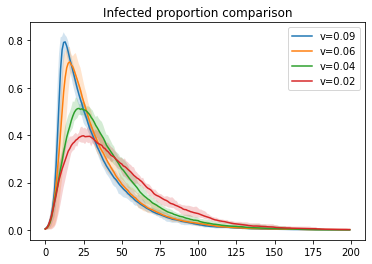

In [20]:
vs = [0.09, 0.06, 0.04, 0.02]
T = 7
n = 500

plt.figure()

for v in vs:

    epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
    bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]

    mean = (epidist['i_mean']/n).tolist()
    lower = (epidist['i_min']/n).tolist()
    upper = (epidist['i_max']/n).tolist()

    meanb = (bepidist['i_mean']/n).tolist()
    lowerb = (bepidist['i_min']/n).tolist()
    upperb = (bepidist['i_max']/n).tolist()

    diff = np.nanmax(mean) - np.nanmax(meanb)
    print(diff)

    # plt.plot(mean,'-b', label="Mean classic model")
    # # fill the area with black color, opacity 0.15
    # plt.fill_between(list(range(len(mean))), upper, lower, color="b", alpha=0.2)

    plt.plot(meanb, label=f"v={v}")
    # fill the area with black color, opacity 0.15
    plt.fill_between(list(range(len(meanb))), upperb, lowerb, alpha=0.2)

plt.title("Infected proportion comparison")
plt.legend(loc="upper right")

plt.show()

{0.3008,0.4106,0.3934,0.2798,0.1786,0.013,0.0154,0.074,0.0022,0.05},
{0.3984,0.2678,0.071,0.0072,0.0006,0.0686,0.0206,0.0172,0.0432,0.0072},
{0.3888,0.0674,0.0828,0.0434,0.099,0.003,0.025,0.0282,0.057,0.0926},
{0.0644,0.0062,0.0012,0.0346,0.011,0.0742,0.0374,0.0102,0.0826,0.0528},
{0.0836,0.0766,0.0238,0.0196,0.2168,0.1022,0.0052,0.0294,0.1264,0.0364},
{0.0216,0.0762,0.0152,0.0072,0.03,0.0698,0.0016,0.1034,0.0892,0.0786},
{0.032,0.1682,0.0036,0.0066,0.061,0.0638,0.112,0.0678,0.0036,0.0048},
{0.1054,0.0952,0.0058,0.0436,0.0268,0.0996,0.0112,0.0952,0.1466,0.0418},
{0.166,0.0704,0.0734,0.0302,0.0282,0.0702,0.0162,0.0148,0.0248,0.0108},


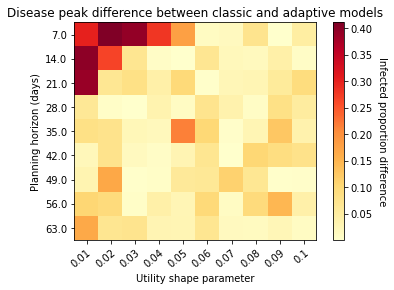

In [21]:
data_diff = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        
        epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean = (epidist['i_mean']/n).tolist()
        meanb = (bepidist['i_mean']/n).tolist()
        
        diff = np.nanmax(mean) - np.nanmax(meanb)
        
        data_diff = pd.concat([data_diff, pd.DataFrame({
            'V': [v],
            'T': [T],
            'diff': [np.abs(diff)]
        })], ignore_index=True)
plot1_data = data_diff.pivot(index='V', columns='T', values='diff')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = "YlOrRd")

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Infected proportion difference", rotation = -90, va = "bottom")
plt.title(f"Disease peak difference between classic and adaptive models")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

### Main figure: global vs local efforts

0.5711762324748587


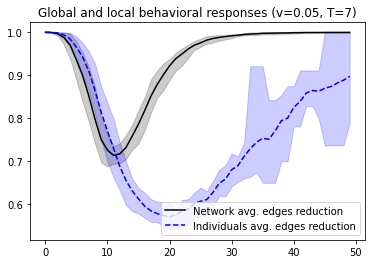

In [22]:
v = 0.05
T = 7
n = 500
epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]

mean_all = bepidist['edgecount_mean'].tolist()
lower_all = bepidist['edgecount_min'].tolist()
upper_all = bepidist['edgecount_max'].tolist()

mean_sus = bepidist['suscedgecount_mean'].tolist()
lower_sus = bepidist['suscedgecount_min'].tolist()
upper_sus = bepidist['suscedgecount_max'].tolist()

print(np.nanmin(bepidist['suscedgecount_mean'].tolist()))

plt.figure()
plt.plot(mean_all[0:50],'-k', label="Network avg. edges reduction")
plt.fill_between(range(50), upper_all[0:50], lower_all[0:50], color="k", alpha=0.2)
plt.plot(mean_sus[0:50], linestyle='--', color='b', label="Individuals avg. edges reduction")
plt.fill_between(range(50), upper_sus[0:50], lower_sus[0:50], color="b", alpha=0.2)
plt.title(f"Global and local behavioral responses (v={v}, T={T})")
plt.legend(loc="lower right")
plt.show()

### Min Avg. Edge Reduction (Global/Local)

{0.6686,0.6739,0.6707,0.7015,0.7137,0.8005,0.8985,0.9234,0.9405,0.9682},
{0.681,0.7048,0.8606,0.9556,0.967,0.9894,1.0,1.0,1.0,1.0},
{0.7137,0.9179,0.9749,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.8522,0.9743,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.9668,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.9837,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},


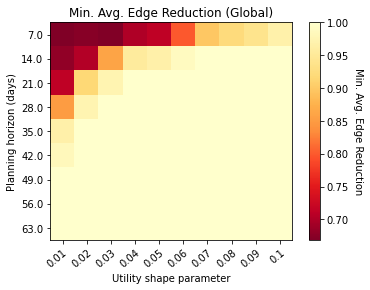

In [23]:
data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_sus = bepidist['edgecount_mean'].tolist()
        min_ctc_sus = np.nanmin(mean_sus)
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [min_ctc_sus]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Min. Avg. Edge Reduction", rotation = -90, va = "bottom")
plt.title(f"Min. Avg. Edge Reduction (Global)")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

{0.6379,0.6456,0.6418,0.5825,0.5712,0.6948,0.8035,0.9442,0.8776,0.9643},
{0.6364,0.5926,0.7011,0.973,0.9805,0.9936,1.0,1.0,1.0,1.0},
{0.6704,0.9231,0.9857,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.8975,0.9844,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.9802,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.9908,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},


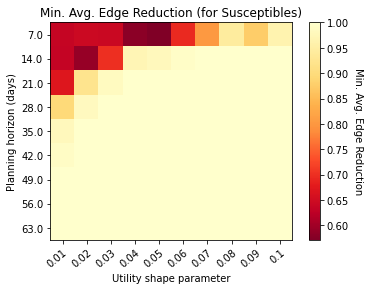

In [25]:
data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_sus = bepidist['suscedgecount_mean'].tolist()
        min_ctc_sus = np.nanmin(mean_sus)
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [min_ctc_sus]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Min. Avg. Edge Reduction", rotation = -90, va = "bottom")
plt.title(f"Min. Avg. Edge Reduction (for Susceptibles)")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

### Day lag between min edge reductions (Global/Local)

{11,9,10,9,9,12,15,0,20,12},
{12,11,12,1,0,0,0,0,0,0},
{11,17,1,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{1,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},


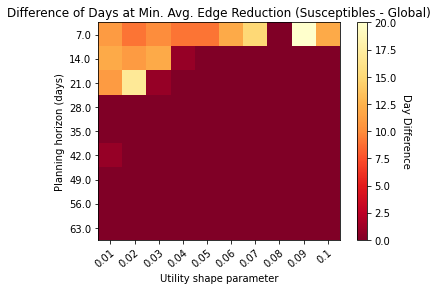

In [26]:
##### Reverse colormap
import matplotlib as mpl

def reverse_colourmap(cmap, name = 'my_cmap_r'):
    """
    In: 
    cmap, name 
    Out:
    my_cmap_r

    Explanation:
    t[0] goes from 0 to 1
    row i:   x  y0  y1 -> t[0] t[1] t[2]
                   /
                  /
    row i+1: x  y0  y1 -> t[n] t[1] t[2]

    so the inverse should do the same:
    row i+1: x  y1  y0 -> 1-t[0] t[2] t[1]
                   /
                  /
    row i:   x  y1  y0 -> 1-t[n] t[2] t[1]
    """        
    reverse = []
    k = []   

    for key in cmap._segmentdata:    
        k.append(key)
        channel = cmap._segmentdata[key]
        data = []

        for t in channel:                    
            data.append((1-t[0],t[2],t[1]))            
        reverse.append(sorted(data))    

    LinearL = dict(zip(k,reverse))
    my_cmap_r = mpl.colors.LinearSegmentedColormap(name, LinearL) 
    return my_cmap_r
cmap = mpl.cm.YlOrRd
cmap_r = reverse_colourmap(cmap)

# ------- #

data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_ctc_ = bepidist['edgecount_mean'].tolist()
        min_ctc_day_ = np.nanargmin(mean_ctc_)
        
        mean_ctc_sus_ = bepidist['suscedgecount_mean'].tolist()
        min_ctc_day_sus_ = np.nanargmin(mean_ctc_sus_)
        
        day_lag_ = min_ctc_day_sus_ - min_ctc_day_
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [day_lag_]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Day Difference", rotation = -90, va = "bottom")
plt.title(f"Difference of Days at Min. Avg. Edge Reduction (Susceptibles - Global)")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

### Population distributions example

In [86]:
dist_example = pd.read_csv('./distribution_example.csv')

dist_example = dist_example.reset_index()
dist_example.columns = ['node', 'v', 'T']

print('Sub population 1: More risk averse. More susceptible to diminish contacts.')
print(dist_example.head(200)['v'].mean())
print(dist_example.head(200)['T'].mean())

print('Sub population 2: Less risk averse. Less susceptible to diminish contacts.')
print(dist_example.tail(300)['v'].mean())
print(dist_example.tail(300)['T'].mean())

Sub population 1: More risk averse. More susceptible to diminish contacts.
0.04938781444981935
6.605
Sub population 2: Less risk averse. Less susceptible to diminish contacts.
0.08031179897296896
15.47


[6, 6, 7, 5, 7, 7, 6, 6, 6, 8, 7, 8, 6, 6, 6, 6, 7, 6, 9, 8, 6, 6, 4, 6, 6, 9, 6, 7, 5, 6, 8, 7, 6, 6, 4, 8, 5, 8, 6, 7, 6, 6, 6, 7, 5, 7, 5, 6, 6, 6, 7, 7, 7, 5, 6, 6, 6, 7, 6, 7, 6, 5, 7, 7, 6, 6, 8, 8, 8, 6, 6, 7, 5, 8, 8, 7, 6, 7, 4, 8, 7, 7, 6, 4, 7, 6, 6, 7, 7, 6, 7, 8, 7, 5, 7, 7, 6, 6, 7, 7, 6, 6, 7, 6, 7, 8, 8, 7, 7, 7, 6, 7, 8, 5, 6, 5, 7, 6, 6, 5, 7, 6, 8, 8, 7, 6, 6, 5, 8, 6, 7, 7, 7, 7, 8, 5, 6, 8, 7, 6, 7, 7, 5, 6, 7, 6, 5, 5, 6, 7, 4, 6, 7, 5, 6, 7, 5, 6, 6, 6, 6, 7, 6, 6, 8, 5, 5, 6, 6, 6, 6, 6, 7, 7, 5, 6, 4, 7, 5, 7, 7, 6, 6, 7, 7, 7, 6, 7, 5, 6, 8, 7, 5, 6, 5, 5, 7, 8, 6, 7]
[16, 16, 16, 17, 17, 17, 17, 17, 15, 16, 14, 15, 13, 16, 15, 16, 18, 16, 16, 14, 16, 17, 16, 16, 16, 15, 16, 15, 13, 14, 16, 15, 14, 15, 16, 16, 16, 15, 16, 15, 17, 15, 14, 13, 15, 16, 16, 16, 16, 17, 17, 16, 16, 15, 15, 16, 17, 16, 16, 16, 15, 15, 18, 15, 15, 16, 16, 15, 14, 17, 15, 16, 17, 15, 16, 16, 13, 16, 18, 14, 15, 16, 17, 16, 15, 15, 15, 16, 16, 16, 16, 13, 14, 15, 16, 16, 17, 15, 14, 18

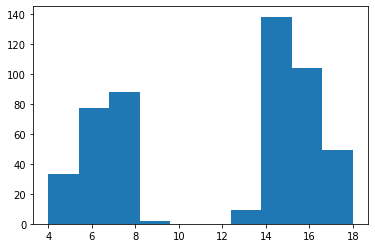

In [165]:
y = dist_example['T']
print(list(y[0:200]))
print(list(y[200:]))
plt.hist(y)
plt.show()

[0.0448660532132682, 0.0516821180201742, 0.0448715537787888, 0.0507753033343336, 0.0503577056109036, 0.0638341391970091, 0.0433147923871066, 0.0512588482192074, 0.0512100331998743, 0.0373720262187334, 0.0542479242888881, 0.0529226687105742, 0.0646762166784813, 0.0452252344432943, 0.0313632744177301, 0.0561094211449824, 0.0523965244720767, 0.0599081934265497, 0.0452111866792487, 0.0581865759145621, 0.05049331498436, 0.054470482451039, 0.04020761970248, 0.0501644450944474, 0.0714930047233998, 0.0648530408469522, 0.0566849167717201, 0.0545506534209482, 0.0622670939360819, 0.0508806047630823, 0.048463983505485, 0.0545155990967598, 0.0447934967890808, 0.0609050721012747, 0.0394846769006893, 0.0331077166573506, 0.0434341765886598, 0.0531883494547846, 0.0536823623512632, 0.0420679943301857, 0.0502663566005928, 0.0455875764680271, 0.0336853594260725, 0.0415668142597098, 0.0445050773428814, 0.0430100603388719, 0.0439646767325739, 0.0266327768990899, 0.0519577954149842, 0.0451677703800992, 0.064

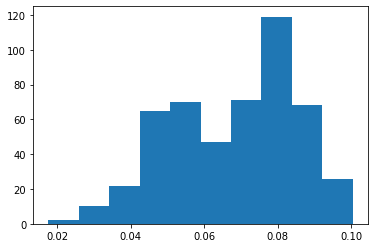

In [166]:
z = dist_example['v']
print(list(z[0:200]))
print(list(z[200:]))
plt.hist(z)
plt.show()

In [43]:
bepidist_data = pd.read_csv('./Data/Distribution_bepidist.csv')
bepidist_data

,day,s_mean,s_min,s_max,s_std,i_mean,i_min,i_max,i_std,r_mean,...,r_max,r_std,edgecount_mean,edgecount_min,edgecount_max,edgecount_std,suscedgecount_mean,suscedgecount_min,suscedgecount_max,suscedgecount_std
0,1,497.82,499,494,1.137308,2.02,5,0,1.078359,0.16,...,0,0.421852,0.999891,1.0,0.999039,0.000198,0.999985,1.0,0.999863,0.000034
1,2,495.80,499,490,2.258770,3.94,10,0,2.235246,0.26,...,0,0.564602,0.999414,1.0,0.995516,0.000874,0.999753,1.0,0.997760,0.000391
2,3,491.04,499,477,5.420897,8.34,21,0,5.117437,0.62,...,0,0.805339,0.997390,1.0,0.988631,0.002801,0.998746,1.0,0.994355,0.001375
3,4,482.16,499,455,10.979313,16.44,42,0,10.361152,1.40,...,0,1.245400,0.991484,1.0,0.967654,0.008358,0.995646,1.0,0.982894,0.004419
4,5,466.72,499,420,20.732544,30.60,74,0,19.368605,2.68,...,0,1.921309,0.978453,1.0,0.930504,0.018322,0.988305,1.0,0.959697,0.010472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,20.26,499,0,98.715590,0.34,2,0,0.592814,479.40,...,1,98.648003,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000
196,197,20.26,499,0,98.715590,0.34,2,0,0.592814,479.40,...,1,98.648003,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000
197,198,20.26,499,0,98.715590,0.30,2,0,0.580288,479.44,...,1,98.656104,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000
198,199,20.26,499,0,98.715590,0.30,2,0,0.580288,479.44,...,1,98.656104,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000


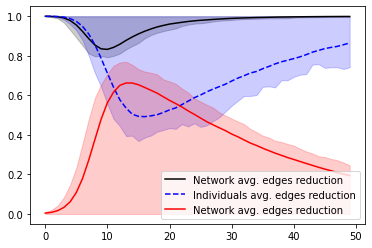

In [44]:
bepidist = bepidist_data.copy()

i_mean = bepidist['i_mean'].astype(float).tolist()
i_mean = [i/500 for i in i_mean]

i_min = bepidist['i_min'].astype(float).tolist()
i_min = [i/500 for i in i_min]

i_max = bepidist['i_max'].astype(float).tolist()
i_max = [i/500 for i in i_max]

mean_all = bepidist['edgecount_mean'].astype(float).tolist()
lower_all = bepidist['edgecount_min'].astype(float).tolist()
upper_all = bepidist['edgecount_max'].astype(float).tolist()

mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()

plt.figure()
plt.plot(mean_all[0:50],'-k', label="Network avg. edges reduction")
plt.fill_between(range(50), upper_all[0:50], lower_all[0:50], color="k", alpha=0.2)
plt.plot(mean_sus[0:50], linestyle='--', color='b', label="Individuals avg. edges reduction")
plt.fill_between(range(50), upper_sus[0:50], lower_sus[0:50], color="b", alpha=0.2)
plt.plot(i_mean[0:50],'-r', label="Network avg. edges reduction")
plt.fill_between(range(50), i_max[0:50], i_min[0:50], color="r", alpha=0.2)
plt.legend(loc="lower right")
plt.show()

#### Examining contact behavior in subpopulations

In [45]:
bepcontacts = pd.read_csv('./Data/Distribution_bepidist_contacts.csv')
print(bepcontacts.shape)
bepcontacts

(25000, 202)


,index,node,day_0,day_1,day_2,day_3,day_4,day_5,day_6,day_7,...,day_190,day_191,day_192,day_193,day_194,day_195,day_196,day_197,day_198,day_199
0,0,0,24,24,24,24,23,22,22,23,...,24,24,24,24,24,24,24,24,24,24
1,0,1,31,31,31,29,27,25,24,24,...,31,31,31,31,31,31,31,31,31,31
2,0,2,27,27,27,27,26,25,23,23,...,27,27,27,27,27,27,27,27,27,27
3,0,3,24,23,23,22,19,21,24,24,...,24,24,24,24,24,24,24,24,24,24
4,0,4,23,23,23,22,22,22,18,16,...,23,23,23,23,23,23,23,23,23,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,49,495,21,21,21,21,21,21,21,18,...,21,21,21,21,21,21,21,21,21,21
24996,49,496,34,34,34,34,34,34,24,24,...,34,34,34,34,34,34,34,34,34,34
24997,49,497,32,32,32,32,32,32,32,32,...,32,32,32,32,32,32,32,32,32,32
24998,49,498,25,25,25,25,25,25,25,25,...,25,25,25,25,25,25,25,25,25,25


In [46]:
bepcontacts_long = pd.melt(bepcontacts, id_vars=['index','node'],
                           value_vars=[col for col in bepcontacts.columns if col.startswith('day')])
bepcontacts_long

,index,node,variable,value
0,0,0,day_0,24
1,0,1,day_0,31
2,0,2,day_0,27
3,0,3,day_0,24
4,0,4,day_0,23
...,...,...,...,...
4999995,49,495,day_199,21
4999996,49,496,day_199,34
4999997,49,497,day_199,32
4999998,49,498,day_199,25


In [47]:
bepcontacts_long_max = bepcontacts_long.groupby(['index', 'node'])['value'].max().reset_index()
bepcontacts_long_max.columns = ['index', 'node', 'value_max']
bepcontacts_long_max

,index,node,value_max
0,0,0,24
1,0,1,31
2,0,2,27
3,0,3,24
4,0,4,23
...,...,...,...
24995,49,495,21
24996,49,496,34
24997,49,497,32
24998,49,498,25


In [48]:
bepcontacts_long_norm = bepcontacts_long.merge(bepcontacts_long_max, left_on=['index', 'node'], right_on=['index', 'node'])
bepcontacts_long_norm['norm_value'] = bepcontacts_long_norm['value']/bepcontacts_long_norm['value_max']
bepcontacts_long_norm['population'] = np.where(bepcontacts_long_norm['node']<200, 1, 2)
bepcontacts_long_norm

,index,node,variable,value,value_max,norm_value,population
0,0,0,day_0,24,24,1.000000,1
1,0,0,day_1,24,24,1.000000,1
2,0,0,day_2,24,24,1.000000,1
3,0,0,day_3,24,24,1.000000,1
4,0,0,day_4,23,24,0.958333,1
...,...,...,...,...,...,...,...
4999995,49,499,day_195,19,19,1.000000,2
4999996,49,499,day_196,19,19,1.000000,2
4999997,49,499,day_197,19,19,1.000000,2
4999998,49,499,day_198,19,19,1.000000,2


In [10]:
bepcontacts_grouped = bepcontacts_long_norm.groupby(['population', 'variable'], as_index=False).agg(
                      {'norm_value':['mean', 'max', 'min', 'std']})
bepcontacts_grouped.columns = bepcontacts_grouped.columns.droplevel()
bepcontacts_grouped.columns = ['pop', 'day', 'mean', 'max', 'min', 'std']
bepcontacts_grouped['day'] = bepcontacts_grouped['day'].apply(lambda x: int(x.replace('day_','')))
bepcontacts_grouped = bepcontacts_grouped.sort_values(['pop', 'day'])
bepcontacts_grouped['lower'] = bepcontacts_grouped['mean'] - bepcontacts_grouped['std']
bepcontacts_grouped['upper'] = bepcontacts_grouped['mean'] + bepcontacts_grouped['std']
bepcontacts_grouped['upper'] = bepcontacts_grouped['upper'].apply(lambda x: min(x,1))
bepcontacts_grouped

,pop,day,mean,max,min,std,lower,upper
0,1,0,0.999830,1.0,0.925000,0.002638,0.997192,1.0
1,1,1,0.999052,1.0,0.850000,0.006914,0.992138,1.0
112,1,2,0.995588,1.0,0.733333,0.017173,0.978415,1.0
123,1,3,0.985884,1.0,0.533333,0.033710,0.952175,1.0
134,1,4,0.965174,1.0,0.578947,0.054368,0.910805,1.0
...,...,...,...,...,...,...,...,...
307,2,195,1.000000,1.0,1.000000,0.000000,1.000000,1.0
308,2,196,1.000000,1.0,1.000000,0.000000,1.000000,1.0
309,2,197,1.000000,1.0,1.000000,0.000000,1.000000,1.0
310,2,198,1.000000,1.0,1.000000,0.000000,1.000000,1.0


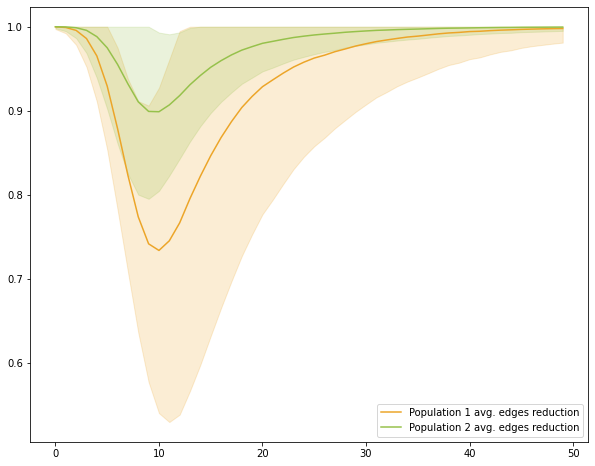

In [59]:
plt.figure(figsize=(10,8))

plt.plot(range(50), bepcontacts_grouped[bepcontacts_grouped['pop']==1]['mean'][0:50],'#ECA528', label="Population 1 avg. edges reduction")
plt.fill_between(range(50),
                bepcontacts_grouped[bepcontacts_grouped['pop']==1]['lower'][0:50],
                bepcontacts_grouped[bepcontacts_grouped['pop']==1]['upper'][0:50],
                color='#ECA528', alpha=0.2)

plt.plot(range(50), bepcontacts_grouped[bepcontacts_grouped['pop']==2]['mean'][0:50],'#96C14B', label="Population 2 avg. edges reduction")
plt.fill_between(range(50),
                bepcontacts_grouped[bepcontacts_grouped['pop']==2]['lower'][0:50],
                bepcontacts_grouped[bepcontacts_grouped['pop']==2]['upper'][0:50],
                color='#96C14B', alpha=0.2)

# plt.plot(mean_all[0:50], linestyle='--', color='k', label="Network individuals avg. edges reduction")
# plt.fill_between(range(50), upper_all[0:50], lower_all[0:50], color='k', alpha=0.2)

plt.legend(loc="lower right")
plt.show()

In [100]:
df = bepcontacts_long_norm.groupby(['node', 'variable'], as_index=False).agg({'norm_value':['mean', 'max', 'min', 'std']})
df.columns = df.columns.droplevel()
df.columns = ['node', 'day', 'mean', 'max', 'min', 'std']
df['day'] = df['day'].apply(lambda x: int(x.replace('day_','')))
df = df.sort_values(by=['node', 'day'])
df = df[df['day'] <=50]

df = df.merge(dist_example, left_on=['node'], right_on=['node'])

df['population'] = 3
df.loc[df['v'].between(0, 0.04, inclusive=True), 'population'] = 1
df.loc[df['v'].between(0.04, 0.05, inclusive=True), 'population'] = 2
print(df['population'].value_counts())

# df['population'] = np.where(df['node']<100, 1, 2)
df1 = df[df['population']==1]
df2 = df[df['population']==2]
df3 = df[df['population']==3]


df0 = df.groupby(['population', 'day'], as_index=False).agg({'mean':['mean', 'max', 'min', 'std']})
df0.columns = df0.columns.droplevel()
df0.columns = ['pop', 'day', 'mean', 'max', 'min', 'std']
df0

3    20043
2     4233
1     1224
Name: population, dtype: int64


C:\Users\jimmy\AppData\Local\Temp/ipykernel_15196/2301966217.py:11: FutureWarning:

Boolean inputs to the `inclusive` argument are deprecated infavour of `both` or `neither`.

C:\Users\jimmy\AppData\Local\Temp/ipykernel_15196/2301966217.py:12: FutureWarning:

Boolean inputs to the `inclusive` argument are deprecated infavour of `both` or `neither`.



,pop,day,mean,max,min,std
0,1,0,0.999803,1.000000,0.998621,0.000409
1,1,1,0.998880,1.000000,0.995172,0.001124
2,1,2,0.994873,1.000000,0.988387,0.002685
3,1,3,0.984602,0.994286,0.965714,0.006374
4,1,4,0.961357,0.980000,0.946667,0.008565
...,...,...,...,...,...,...
148,3,46,0.999237,1.000000,0.990000,0.001114
149,3,47,0.999302,1.000000,0.990000,0.001087
150,3,48,0.999382,1.000000,0.990000,0.001019
151,3,49,0.999445,1.000000,0.990909,0.000915


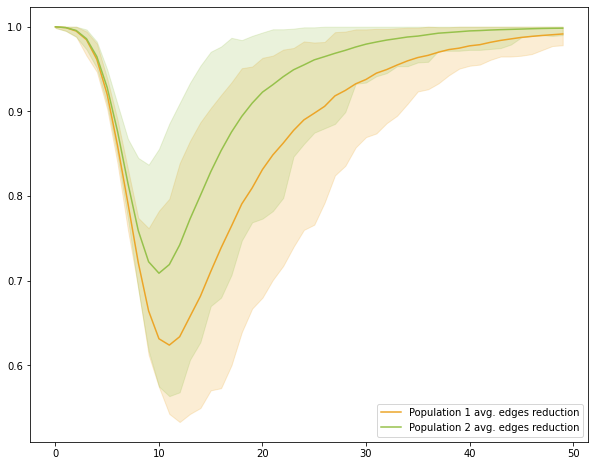

In [101]:
plt.figure(figsize=(10,8))

plt.plot(range(50), df0[df0['pop']==1]['mean'][0:50],'#ECA528', label="Population 1 avg. edges reduction")
plt.fill_between(range(50),
                df0[df0['pop']==1]['min'][0:50],
                df0[df0['pop']==1]['max'][0:50],
                color='#ECA528', alpha=0.2)

plt.plot(range(50), df0[df0['pop']==2]['mean'][0:50],'#96C14B', label="Population 2 avg. edges reduction")
plt.fill_between(range(50),
                df0[df0['pop']==2]['min'][0:50],
                df0[df0['pop']==2]['max'][0:50],
                color='#96C14B', alpha=0.2)

# plt.plot(range(50), df0[df0['pop']==3]['mean'][0:50],'red', label="Population 3 avg. edges reduction")
# plt.fill_between(range(50),
#                 df0[df0['pop']==3]['min'][0:50],
#                 df0[df0['pop']==3]['max'][0:50],
#                 color='red', alpha=0.2)

#plt.plot(mean_all[0:50], linestyle='--', color='k', label="Network individuals avg. edges reduction")
#plt.fill_between(range(50), upper_all[0:50], lower_all[0:50], color='k', alpha=0.2)

plt.legend(loc="lower right")
plt.show()

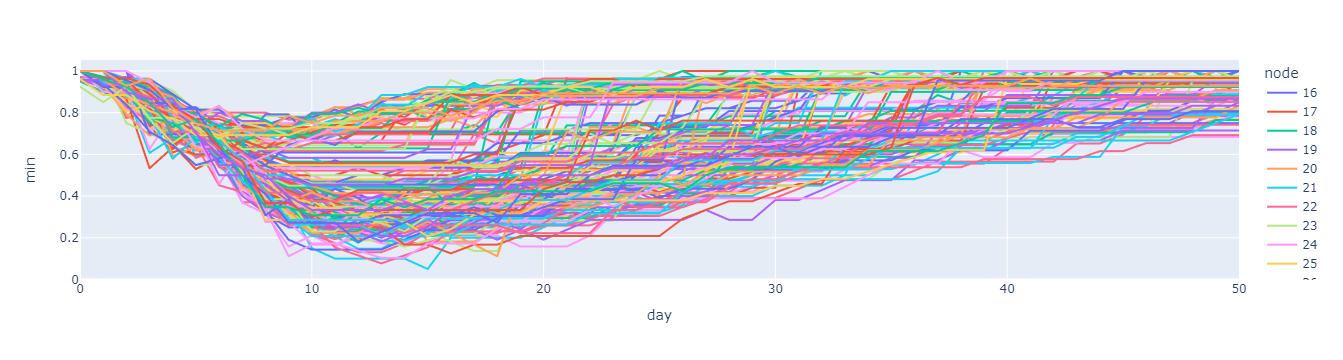

In [82]:
import plotly.express as px
fig = px.line(df2, x="day", y="min", color='node')
fig.show()

In [39]:
dist_example.iloc[81]

v    0.027947
T    7.000000
Name: 81, dtype: float64

In [40]:
dist_example.iloc[120]

v    0.062628
T    7.000000
Name: 120, dtype: float64

In [42]:
dist_example.iloc[181]

v    0.058896
T    7.000000
Name: 181, dtype: float64

In [41]:
dist_example.iloc[152]

v    0.031864
T    6.000000
Name: 152, dtype: float64

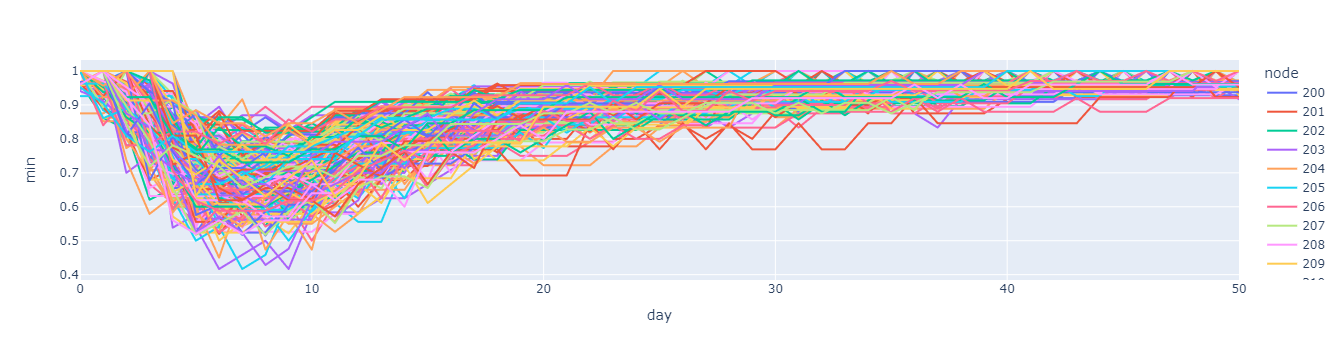

In [38]:
fig = px.line(df2, x="day", y="min", color='node')
fig.show()

### Bifurcation plot examination
Not important ...

In [71]:
# epidist_data = pd.read_csv('./Data/epidist_bifurcation.csv')
# bepidist_data = pd.read_csv('./Data/bepidist_bifurcation.csv')
# epidist_data =  epidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
# epidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
# 'r_mean', 'r_min', 'r_max', 'pi', 'pr']
# epidist_data = epidist_data.apply(pd.to_numeric)
# epidist_data
# bepidist_data = bepidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
# bepidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
#                          'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
# 'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'pi', 'pr']
# bepidist_data = bepidist_data.apply(pd.to_numeric)
# bepidist_data
# dat = pd.DataFrame(epidist_data.groupby(['pi'])['i_mean'].mean()).reset_index()
# plt.scatter(dat['pi'], dat['i_mean'])
# plt.show()
# dat = pd.DataFrame(bepidist_data.groupby(['pi'])['i_mean'].mean()).reset_index()
# plt.scatter(dat['pi'], dat['i_mean'])
# plt.show()
# dat1 = epidist_data[epidist_data['pi']==0.0069]
# dat2 = bepidist_data[bepidist_data['pi']==0.0069]
# print(dat1['i_mean'].max())
# print(dat2['i_mean'].max())
# print(dat1['i_mean'].mean())
# print(dat2['i_mean'].mean())
# plt.plot(range(dat1.shape[0]), dat1['i_mean'], range(dat1.shape[0]), dat2['i_mean'])
# plt.show()
# diffs = []
# mean_diffs = []
# for pi in epidist_data['pi'].unique().tolist():
#     dat1 = epidist_data[epidist_data['pi']==pi]
#     dat2 = bepidist_data[bepidist_data['pi']==pi]
#     diff = dat1['i_mean'].max() - dat2['i_mean'].max()
#     diffs.append(diff)
#     mean_diff = dat1['i_mean'].mean() - dat2['i_mean'].mean()
#     mean_diffs.append(mean_diff)
# plt.plot(epidist_data['pi'].unique().tolist(), mean_diffs)
# plt.show()
# plt.plot(epidist_data['pi'].unique().tolist(), diffs)
# plt.show()

## Sensitivity to network connectivity

Experiment with Erdos-Renyi

In [6]:
bepidist_data_c = pd.read_csv('./Data/bepidist_ntwk_conn_erdos_renyi.csv')
bepidist_data_c = bepidist_data_c.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data_c.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
                         'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'ped']
bepidist_data_c = bepidist_data_c.apply(pd.to_numeric)
conns = bepidist_data_c['ped'].unique().tolist()[5:]
conns = [con for con in conns if con >=0.01]

In [7]:
day_lags = []
for conn in conns:

    bepidist = bepidist_data_c.copy()
    bepidist = bepidist[bepidist['ped'] == conn]

    i_mean = bepidist['i_mean'].astype(float).tolist()
    i_mean = [i/500 for i in i_mean]

    i_min = bepidist['i_min'].astype(float).tolist()
    i_min = [i/500 for i in i_min]

    i_max = bepidist['i_max'].astype(float).tolist()
    i_max = [i/500 for i in i_max]

    mean_all = bepidist['edgecount_mean'].astype(float).tolist()
    lower_all = bepidist['edgecount_min'].astype(float).tolist()
    upper_all = bepidist['edgecount_max'].astype(float).tolist()

    mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
    lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
    upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()
    
    day_lags.append(np.nanargmin(mean_sus) - np.nanargmin(mean_all))

    # plt.figure()
    # days = 50
    # plt.plot(mean_all[0:days],'-k', label="Network avg. edges reduction")
    # plt.fill_between(list(range(len(mean_all[0:days]))), upper_all[0:days], lower_all[0:days], color="k", alpha=0.2)
    # plt.plot(mean_sus[0:days], linestyle='--', color='b', label="Individuals avg. edges reduction")
    # plt.fill_between(list(range(len(mean_sus[0:days]))), upper_sus[0:days], lower_sus[0:days], color="b", alpha=0.2)
    # plt.plot(i_mean[0:days],'-r', label="Infected Proportion")
    # plt.fill_between(list(range(len(i_mean[0:days]))), i_max[0:days], i_min[0:days], color="r", alpha=0.2)
    # plt.legend(loc="lower right")
    # plt.title(f"Edge reduction (global/local) and infected population. Connectivity={conn}")
    # plt.xlabel("Time")
    # plt.show()

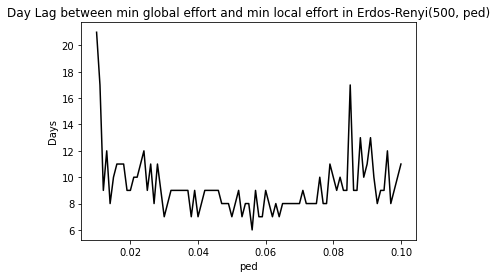

In [8]:
plt.figure()
plt.plot(conns, day_lags,'-k', label="Network avg. edges reduction")
plt.title("Day Lag between min global effort and min local effort in Erdos-Renyi(500, ped)")
plt.xlabel("ped")
plt.ylabel("Days")
plt.show()

### Barabasi Albert Network

In [58]:
bepidist_data_ba = pd.read_csv('./Data/bepidist_ntwk_barabasi_albert.csv')
bepidist_data_ba = bepidist_data_ba.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data_ba.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
                         'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'm']
bepidist_data_ba = bepidist_data_ba.apply(pd.to_numeric)
mms = bepidist_data_ba['m'].unique().tolist()

In [60]:
day_lags = []

for m in mms:
    
    bepidist = bepidist_data_ba.copy()
    bepidist = bepidist[bepidist['m'] == m]

    i_mean = bepidist['i_mean'].astype(float).tolist()
    i_mean = [i/500 for i in i_mean]

    i_min = bepidist['i_min'].astype(float).tolist()
    i_min = [i/500 for i in i_min]

    i_max = bepidist['i_max'].astype(float).tolist()
    i_max = [i/500 for i in i_max]

    mean_all = bepidist['edgecount_mean'].astype(float).tolist()
    lower_all = bepidist['edgecount_min'].astype(float).tolist()
    upper_all = bepidist['edgecount_max'].astype(float).tolist()

    mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
    lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
    upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()

    day_lags.append(np.nanargmin(mean_sus) - np.nanargmin(mean_all))

    # plt.figure()
    # days = 50
    # plt.plot(mean_all[0:days],'-k', label="Network avg. edges reduction")
    # plt.fill_between(list(range(len(mean_all[0:days]))), upper_all[0:days], lower_all[0:days], color="k", alpha=0.2)
    # plt.plot(mean_sus[0:days], linestyle='--', color='b', label="Individuals avg. edges reduction")
    # plt.fill_between(list(range(len(mean_sus[0:days]))), upper_sus[0:days], lower_sus[0:days], color="b", alpha=0.2)
    # plt.plot(i_mean[0:days],'-r', label="Infected Proportion")
    # plt.fill_between(list(range(len(i_mean[0:days]))), i_max[0:days], i_min[0:days], color="r", alpha=0.2)
    # plt.legend(loc="lower right")
    # plt.title(f"Edge reduction (global/local) and infected population. Barabasi-Alberti(500, {int(m)})")
    # plt.xlabel("Time")
    # plt.show()

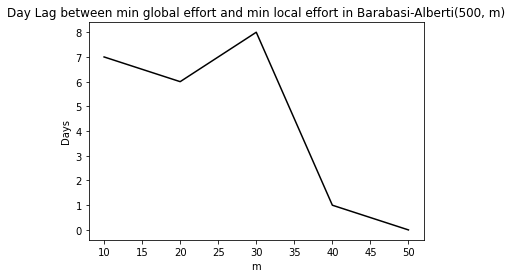

In [61]:
plt.figure()
days = 50
plt.plot(mms, day_lags,'-k', label="Network avg. edges reduction")
plt.title("Day Lag between min global effort and min local effort in Barabasi-Albert(500, m)")
plt.xlabel("m")
plt.ylabel("Days")
plt.show()

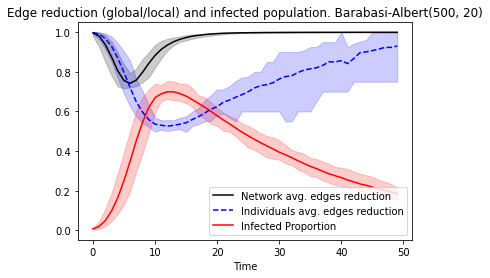

In [74]:
m = 20 
bepidist = bepidist_data_ba.copy()
bepidist = bepidist[bepidist['m'] == m]

i_mean = bepidist['i_mean'].astype(float).tolist()
i_mean = [i/500 for i in i_mean]

i_min = bepidist['i_min'].astype(float).tolist()
i_min = [i/500 for i in i_min]

i_max = bepidist['i_max'].astype(float).tolist()
i_max = [i/500 for i in i_max]

mean_all = bepidist['edgecount_mean'].astype(float).tolist()
lower_all = bepidist['edgecount_min'].astype(float).tolist()
upper_all = bepidist['edgecount_max'].astype(float).tolist()

mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()

day_lags.append(np.nanargmin(mean_sus) - np.nanargmin(mean_all))

plt.figure()
days = 50
plt.plot(mean_all[0:days],'-k', label="Network avg. edges reduction")
plt.fill_between(list(range(len(mean_all[0:days]))), upper_all[0:days], lower_all[0:days], color="k", alpha=0.2)
plt.plot(mean_sus[0:days], linestyle='--', color='b', label="Individuals avg. edges reduction")
plt.fill_between(list(range(len(mean_sus[0:days]))), upper_sus[0:days], lower_sus[0:days], color="b", alpha=0.2)
plt.plot(i_mean[0:days],'-r', label="Infected Proportion")
plt.fill_between(list(range(len(i_mean[0:days]))), i_max[0:days], i_min[0:days], color="r", alpha=0.2)
plt.legend(loc="lower right")
plt.title(f"Edge reduction (global/local) and infected population. Barabasi-Albert(500, {int(m)})")
plt.xlabel("Time")
plt.show()

### Small world network

- n : int
The number of nodes

- k : int
Each node is connected to k nearest neighbors in ring topology

- p : float
The probability of rewiring each edge

In [25]:
bepidist_data_sw = pd.read_csv('./Data/bepidist_ntwk_small_world.csv')
bepidist_data_sw = bepidist_data_sw.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data_sw.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
                         'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'm', 'ped']
bepidist_data_sw = bepidist_data_sw.apply(pd.to_numeric)

In [45]:
dat_ = pd.DataFrame({})

for m in bepidist_data_sw['m'].unique():
    for ped in bepidist_data_sw['ped'].unique():
        
        bepidist = bepidist_data_sw[(bepidist_data_sw['m']==m) & (bepidist_data_sw['ped']==ped)]
        mean_all = bepidist['edgecount_mean'].astype(float).tolist()
        mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
        day_lag = np.nanargmin(mean_sus) - np.nanargmin(mean_all)
        
        dat_ = pd.concat([dat_, pd.DataFrame({
            'm': [int(m)],
            'ped': [ped],
            'day_lag': [day_lag]
        })], ignore_index=True)

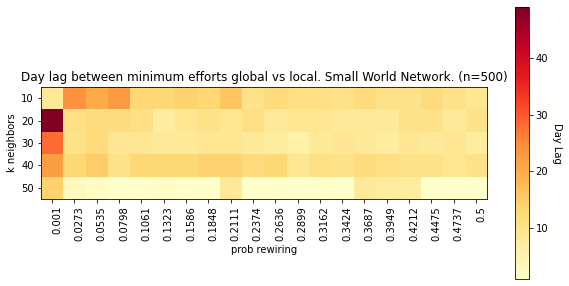

In [48]:
plot1_data = dat_.pivot(index='ped', columns='m', values='day_lag')

# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = "YlOrRd")

ax.figure.set_size_inches(10, 5)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 90,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Day Lag", rotation = -90, va = "bottom")
plt.title(f"Day lag between minimum efforts global vs local. Small World Network. (n=500)")
plt.xlabel("prob rewiring")
plt.ylabel("k neighbors") 
plt.show()
# Add 2D lines several lines.

In [50]:
bepidist_data_sw['ped'].unique()

array([0.001 , 0.0273, 0.0535, 0.0798, 0.1061, 0.1323, 0.1586, 0.1848,
       0.2111, 0.2374, 0.2636, 0.2899, 0.3162, 0.3424, 0.3687, 0.3949,
       0.4212, 0.4475, 0.4737, 0.5   ])

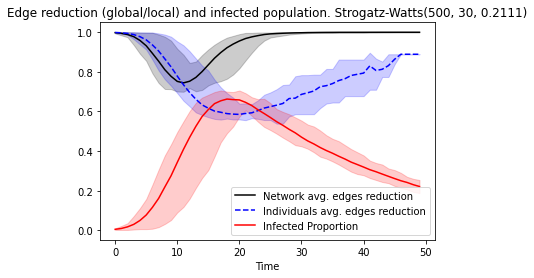

In [52]:
m = 30
ped = 0.2111

bepidist = bepidist_data_sw[(bepidist_data_sw['m']==m) & (bepidist_data_sw['ped']==ped)]

i_mean = bepidist['i_mean'].astype(float).tolist()
i_mean = [i/500 for i in i_mean]

i_min = bepidist['i_min'].astype(float).tolist()
i_min = [i/500 for i in i_min]

i_max = bepidist['i_max'].astype(float).tolist()
i_max = [i/500 for i in i_max]

mean_all = bepidist['edgecount_mean'].astype(float).tolist()
lower_all = bepidist['edgecount_min'].astype(float).tolist()
upper_all = bepidist['edgecount_max'].astype(float).tolist()

mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()

day_lags.append(np.nanargmin(mean_sus) - np.nanargmin(mean_all))

plt.figure()
days = 50
plt.plot(mean_all[0:days],'-k', label="Network avg. edges reduction")
plt.fill_between(list(range(len(mean_all[0:days]))), upper_all[0:days], lower_all[0:days], color="k", alpha=0.2)
plt.plot(mean_sus[0:days], linestyle='--', color='b', label="Individuals avg. edges reduction")
plt.fill_between(list(range(len(mean_sus[0:days]))), upper_sus[0:days], lower_sus[0:days], color="b", alpha=0.2)
plt.plot(i_mean[0:days],'-r', label="Infected Proportion")
plt.fill_between(list(range(len(i_mean[0:days]))), i_max[0:days], i_min[0:days], color="r", alpha=0.2)
plt.legend(loc="lower right")
plt.title(f"Edge reduction (global/local) and infected population. Watts-Strogatz(500, {int(m)}, {ped})")
plt.xlabel("Time")
plt.show()

## Articles of interest:
- https://www.pnas.org/doi/10.1073/pnas.2123355119
- https://journals.aps.org/pre/pdf/10.1103/PhysRevE.88.042802
- https://journals.aps.org/pre/pdf/10.1103/PhysRevE.77.066101
- https://journals.aps.org/prl/pdf/10.1103/PhysRevLett.96.208701
- https://www.sciencedirect.com/science/article/pii/S0022039618304182
- https://ieeexplore.ieee.org/abstract/document/8502826